# Analisis de sentimientos en Twitter
### Autor: Diego Castro Satt

In [46]:
#importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [47]:
train = pd.read_csv('twitter_training.csv')
train.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [48]:
train.columns = ["id","topic","sentiment","text"]
train.columns


Index(['id', 'topic', 'sentiment', 'text'], dtype='str')

In [49]:
labels = {
    "Negative":0,
    "Neutral":1,
    "Positive":2,
    "Irrelevant":3
}
train["label"] = train["sentiment"].map(labels)

## EDA

In [50]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         74681 non-null  int64
 1   topic      74681 non-null  str  
 2   sentiment  74681 non-null  str  
 3   text       73995 non-null  str  
 4   label      74681 non-null  int64
dtypes: int64(2), str(3)
memory usage: 2.8 MB


In [51]:
train.describe()

,id,label
count,74681.000000,74681.000000
mean,6432.640149,1.324969
std,3740.423819,1.082103
min,1.000000,0.000000
25%,3195.000000,0.000000
50%,6422.000000,1.000000
75%,9601.000000,2.000000
max,13200.000000,3.000000


In [52]:
train.isnull().sum()

id             0
topic          0
sentiment      0
text         686
label          0
dtype: int64

In [53]:
train.dropna(inplace=True) # Eliminar filas con valores nulos

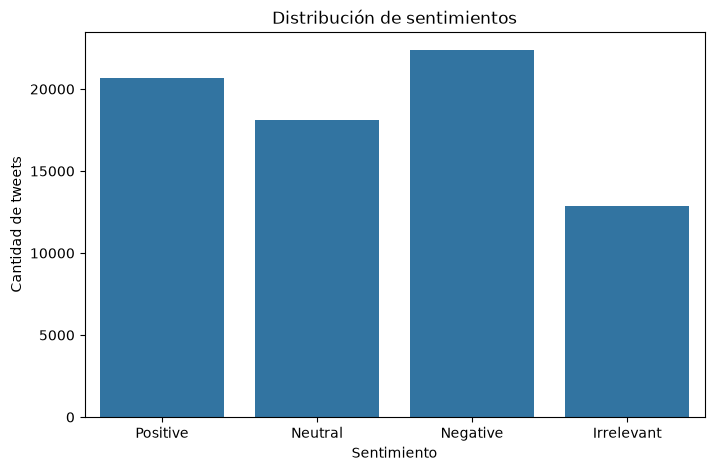

In [54]:
plt.figure(figsize=(8,5))
sns.countplot(data=train, x="sentiment")
plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")
plt.show()

In [55]:
# porcentaje de cada sentimiento en el conjunto de entrenamiento
train["sentiment"].value_counts(normalize=True)*100

sentiment
Negative      30.215555
Positive      27.912697
Neutral       24.471924
Irrelevant    17.399824
Name: proportion, dtype: float64

### Los temas mas frecuentes

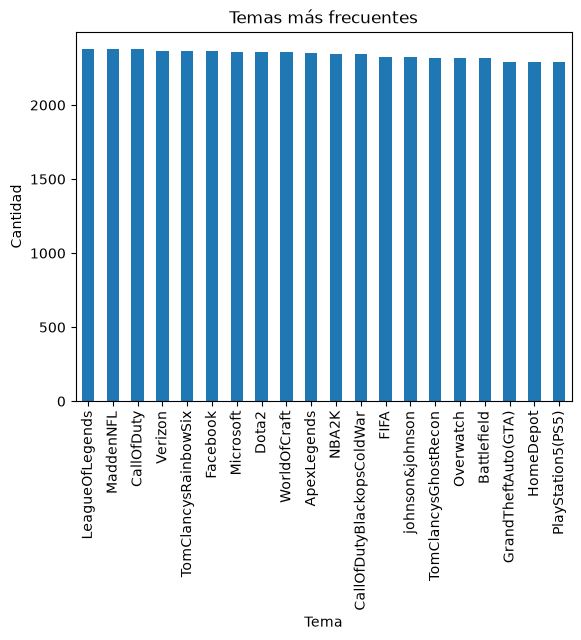

In [56]:
train["topic"].value_counts().head(20).sort_values(ascending=False).plot(kind="bar") 
plt.title("Temas más frecuentes") 
plt.xlabel("Tema")
plt.ylabel("Cantidad");
plt.xticks(rotation=90)
plt.show()

### Longitud de tweets

In [57]:
train["text_length"] = (
    train["text"]
    .astype(str)
    .apply(len)
)


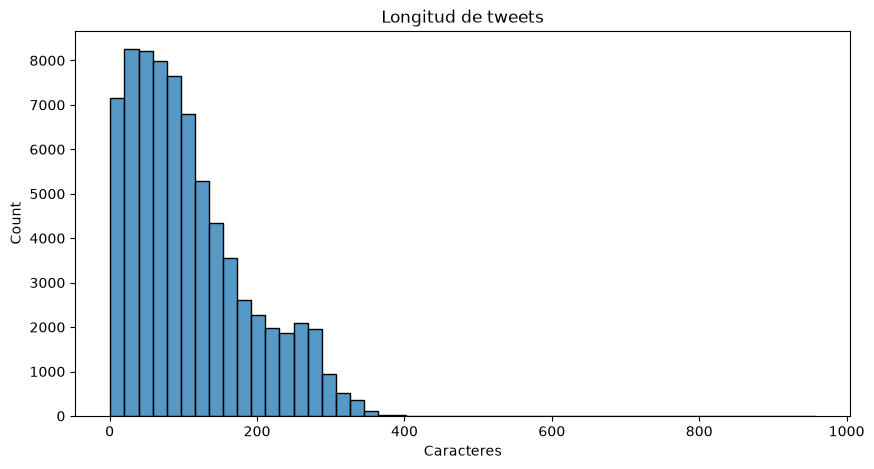

In [58]:
plt.figure(figsize=(10,5))
sns.histplot(train["text_length"], bins=50)
plt.title("Longitud de tweets")
plt.xlabel("Caracteres")
plt.show()

In [59]:
# Cantidad de palabras por tweet en el conjunto de entrenamiento
train["word_count"] = train["text"].astype(str).apply(lambda x: len(x.split()))
train[["text", "word_count"]].head()

,text,word_count
0,I am coming to the borders and I will kill you...,12
1,im getting on borderlands and i will kill you ...,10
2,im coming on borderlands and i will murder you...,10
3,im getting on borderlands 2 and i will murder ...,12
4,im getting into borderlands and i can murder y...,10


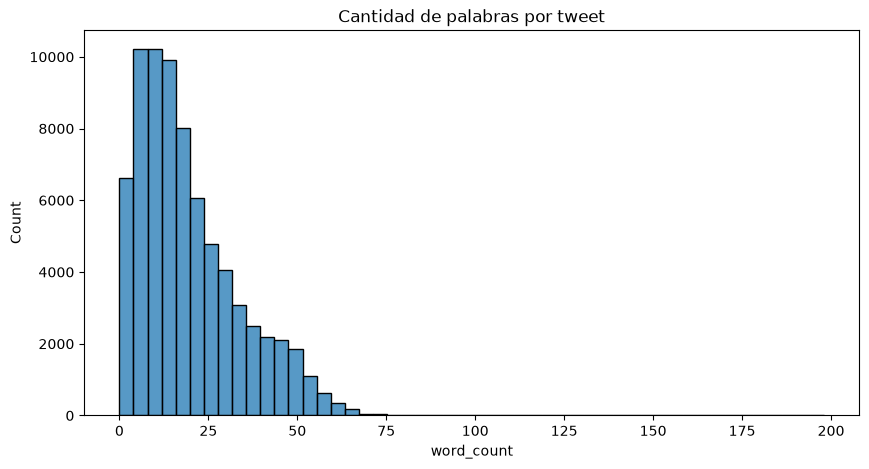

In [60]:
plt.figure(figsize=(10,5))
sns.histplot(train["word_count"], bins=50)
plt.title("Cantidad de palabras por tweet")
plt.show()

### Palabras más frecuentes

In [61]:
all_words = " ".join(train["text"].astype(str))
words = all_words.split()
frequency = Counter(words)
frequency.most_common(20)

[('the', 38246),
 ('to', 27711),
 ('I', 25185),
 ('and', 24652),
 ('a', 21851),
 ('of', 18627),
 ('is', 16473),
 ('for', 14714),
 ('/', 14655),
 ('in', 14088),
 ('@', 11081),
 ('on', 11067),
 ('this', 10536),
 ('.', 10201),
 ('my', 10120),
 ('it', 9652),
 ('you', 9465),
 ('that', 9023),
 ('with', 8286),
 ('have', 6250)]

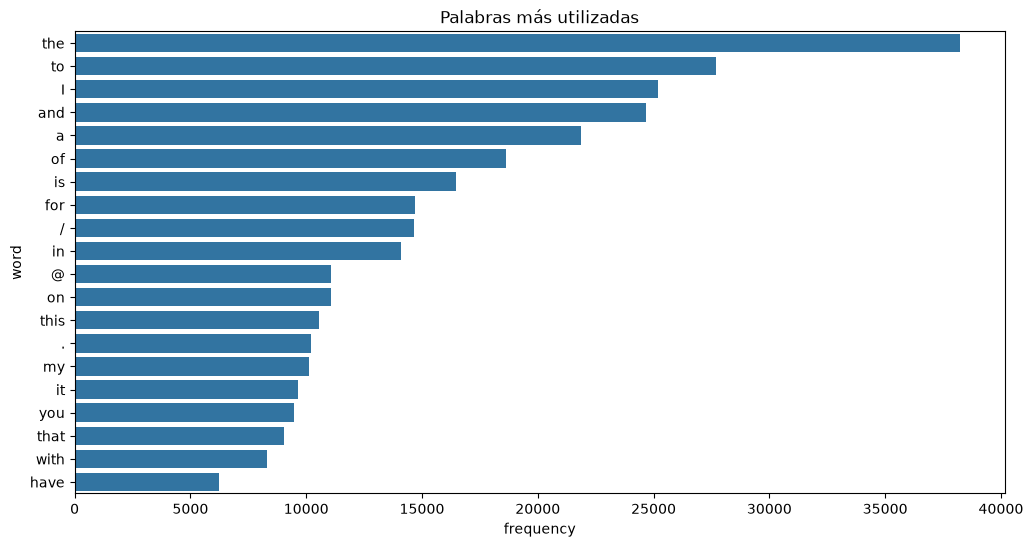

In [62]:
common_words = pd.DataFrame(frequency.most_common(20), columns=["word", "frequency"])
plt.figure(figsize=(12,6))
sns.barplot(data=common_words, x="frequency", y="word")
plt.title("Palabras más utilizadas")
plt.show()

In [63]:
label_map = {"Negative":0, "Neutral":1, "Positive":2, "Irrelevant":3}
train["label"] = train["sentiment"].map(label_map)
train.head()

,id,topic,sentiment,text,label,text_length,word_count
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,2,51,12
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,2,50,10
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,2,51,10
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,2,57,12
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,2,53,10


## Token 

In [64]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [65]:
texto = "I love this game"
tokens = tokenizer(texto, padding=True, truncation=True, return_tensors="pt")
tokens

{'input_ids': tensor([[ 101, 1045, 2293, 2023, 2208,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

## Dataset


In [66]:
class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [67]:
X_train, X_test, y_train, y_test = train_test_split(train["text"].values, train["label"].values, test_size=0.2, random_state=42)

In [68]:
train_dataset = TwitterDataset(X_train, y_train, tokenizer)
test_dataset = TwitterDataset(X_test, y_test, tokenizer)

In [69]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)


training_args = TrainingArguments(
    output_dir="./twitter_model",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [70]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return { "accuracy": accuracy_score(labels, predictions)}

In [71]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [90]:
results = trainer.predict(test_dataset)
y_pred = np.argmax(results.predictions, axis=1)

results = trainer.predict(test_subset)
y_true = y_test[test_subset.indices]



In [93]:
print(len(y_true), len(y_pred))

14799 14799


In [94]:
print(classification_report(
    y_true,
    y_pred,
    labels=[0,1,2,3],
    target_names=["Negative", "Neutral", "Positive", "Irrelevant"],
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.16      0.05      0.07      4463
     Neutral       0.19      0.39      0.26      3589
    Positive       0.25      0.39      0.31      4123
  Irrelevant       0.00      0.00      0.00      2624

    accuracy                           0.22     14799
   macro avg       0.15      0.21      0.16     14799
weighted avg       0.17      0.22      0.17     14799



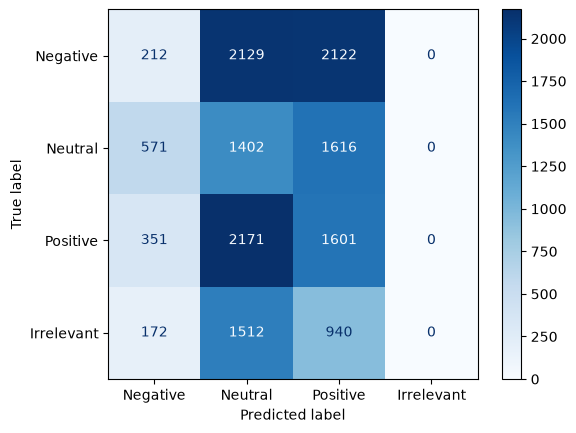

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive", "Irrelevant"]
)

disp.plot(cmap="Blues")
plt.show()

## Predicción de tweets

In [107]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [108]:
print(next(model.parameters()).device)
print(device)

mps:0
mps


In [ ]:
def predecir_sentimiento(texto):
    model.eval()
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    probabilidades = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probabilidades, dim=1).item()
    traduccion = {
        "LABEL_0": "Negative",
        "LABEL_1": "Neutral",
        "LABEL_2": "Positive",
        "LABEL_3": "Irrelevant"
    }

    etiqueta_modelo = model.config.id2label[pred]
    sentimiento = traduccion.get(etiqueta_modelo, etiqueta_modelo)

    print(f"Texto: {texto}")
    print(f"Sentimiento: {sentimiento}")
    print(f"Confianza: {probabilidades[0][pred].item()*100:.2f}%")

Pruebas

In [132]:
predecir_sentimiento("I have been playing this game for several months and I really wanted to enjoy it because the graphics are amazing and the gameplay has a lot of potential. However, after the latest update, the experience has become frustrating. The servers disconnect frequently, matchmaking takes too long, and there are several bugs that make missions impossible to complete. Customer support has not responded to my requests, which makes the situation even worse. Although I still think the game has a great concept and I appreciate the effort of the developers, at the moment I cannot recommend it to anyone until these issues are fixed.")

Texto: I have been playing this game for several months and I really wanted to enjoy it because the graphics are amazing and the gameplay has a lot of potential. However, after the latest update, the experience has become frustrating. The servers disconnect frequently, matchmaking takes too long, and there are several bugs that make missions impossible to complete. Customer support has not responded to my requests, which makes the situation even worse. Although I still think the game has a great concept and I appreciate the effort of the developers, at the moment I cannot recommend it to anyone until these issues are fixed.
Sentimiento: Neutral
Confianza: 27.58%


In [121]:
predecir_sentimiento("I was really excited to try this game after reading so many positive reviews, but it ended up being a huge disappointment. The performance is terrible, with constant lag and crashes, the controls feel unresponsive, and the missions quickly become repetitive. On top of that, the game is filled with expensive microtransactions that make progression frustrating unless you spend money. I regret buying it and I don't think I'll be playing it again unless major improvements are made.")

Texto: I was really excited to try this game after reading so many positive reviews, but it ended up being a huge disappointment. The performance is terrible, with constant lag and crashes, the controls feel unresponsive, and the missions quickly become repetitive. On top of that, the game is filled with expensive microtransactions that make progression frustrating unless you spend money. I regret buying it and I don't think I'll be playing it again unless major improvements are made.
Sentimiento: Neutral
Confianza: 26.85%
